# Advanced Econometric Event Study & GARCH(1,1) Volatility Analysis
**Project:** Quantitative Impact of Global and Domestic Events on the BIST 100
**Author:** Yigit Keskin

---

### Overview & Evolution Beyond Baseline Analysis
After completing the initial exploratory data analysis (EDA), hypothesis tests, and machine learning models, this notebook implements advanced econometric and asset pricing methodologies:

1. **Market Model (CAPM) Benchmark Decoupling:** Isolating Turkey-specific abnormal returns (AR) by stripping out emerging market beta using the MSCI Emerging Markets ETF (EEM) over an estimation window (T in [-250, -30]).
2. **Cumulative Abnormal Returns (CAR) & Buy-and-Hold (BHAR):** Evaluating cumulative returns across an event window ([-5, +5] trading days).
3. **Econometric Hypothesis Testing:**
   - **Patell (1976) Z-Test:** Parametric test weighted by estimation residual variance.
   - **Boehmer, Musumeci, Poulsen (BMP 1991) Test:** Robust to event-induced cross-sectional variance shifts.
4. **Volatility Dynamics & GARCH(1,1):** Modeling conditional variance with Student-t innovations, estimating shock persistence (alpha_1 + beta_1), and calculating the half-life of market fear in trading days.

In [1]:
import os
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from arch import arch_model

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Ingestion & Emerging Markets Benchmark Alignment
We load our unified BIST 100 daily data and macro shock catalog, then pull or load the MSCI Emerging Markets Index (EEM) as our benchmark.

In [2]:
DATA_DIR = Path("..") / "data_collection" / "processed"
df_bist = pd.read_csv(DATA_DIR / "unified_bist_data.csv")
df_shocks = pd.read_csv(DATA_DIR / "shock_analysis_summary.csv")

df_bist["date"] = pd.to_datetime(df_bist["date"])
df_shocks["date"] = pd.to_datetime(df_shocks["date"])
df_bist = df_bist.sort_values("date").reset_index(drop=True)
df_shocks = df_shocks.sort_values("date").reset_index(drop=True)

if "daily_return" not in df_bist.columns:
    df_bist["daily_return"] = df_bist["close"].pct_change()

bench_cache = DATA_DIR / "EEM_benchmark.csv"
if bench_cache.exists():
    df_bench = pd.read_csv(bench_cache)
    df_bench["date"] = pd.to_datetime(df_bench["date"])
else:
    print("Fetching EEM from Yahoo Finance...")
    raw = yf.download("EEM", start="2014-12-01", end="2026-04-01", progress=False)
    close_s = raw["Close"].iloc[:, 0] if isinstance(raw.columns, pd.MultiIndex) else raw["Close"]
    df_bench = close_s.reset_index()
    df_bench.columns = ["date", "close_benchmark"]
    df_bench["date"] = pd.to_datetime(df_bench["date"]).dt.tz_localize(None)
    df_bench["bench_return"] = df_bench["close_benchmark"].pct_change()
    df_bench = df_bench.dropna().sort_values("date").reset_index(drop=True)
    df_bench.to_csv(bench_cache, index=False)

panel = pd.merge(df_bist, df_bench[["date", "bench_return"]], on="date", how="left")
panel["bench_return"] = panel["bench_return"].ffill().bfill()

print(f"Market Panel ready: {len(panel):,} trading sessions | Shock events: {len(df_shocks)}")
panel[["date", "close", "daily_return", "bench_return"]].tail()

Market Panel ready: 2,817 trading sessions | Shock events: 24


,date,close,daily_return,bench_return
2812,2026-03-30,12626.400391,-0.005654,-0.008152
2813,2026-03-31,12791.000000,0.013036,0.037260
2814,2026-04-01,12937.900391,0.011485,0.037260
2815,2026-04-02,13051.700195,0.008796,0.037260
2816,2026-04-03,12936.400391,-0.008834,0.037260


## 2. Econometric Event Study Engine
For each macro event, we fit an OLS Market Model over the estimation window (T in [-250, -30]):
R_BIST = alpha + beta * R_EEM + epsilon
We then compute daily Abnormal Returns (AR), Cumulative Abnormal Returns (CAR), and Buy-and-Hold Abnormal Returns (BHAR) across the [-5, +5] event window.

In [3]:
@dataclass
class SingleEventOutput:
    event_name: str
    event_date: pd.Timestamp
    category: str
    severity: str
    alpha: float
    beta: float
    r_squared: float
    residuals_std: float
    event_df: pd.DataFrame
    car_pct: float
    bhar_pct: float

class EconometricEventStudy:
    def __init__(self, panel, estimation_window=(-250, -30), event_window=(-5, 5)):
        self.panel = panel.sort_values("date").reset_index(drop=True)
        self.est_start, self.est_end = estimation_window
        self.evt_start, self.evt_end = event_window

    def run_event(self, event_name, event_date, category, severity):
        future = self.panel[self.panel["date"] >= event_date]
        if future.empty:
            return None
        t0_idx = future.index[0]

        est_s = t0_idx + self.est_start
        est_e = t0_idx + self.est_end
        evt_s = t0_idx + self.evt_start
        evt_e = t0_idx + self.evt_end

        if est_s < 0 or evt_e >= len(self.panel):
            return None

        est_df = self.panel.iloc[est_s : est_e + 1].dropna(subset=["daily_return", "bench_return"])
        if len(est_df) < 60:
            return None

        Y = est_df["daily_return"].values
        X_bench = est_df["bench_return"].values
        X_mat = np.column_stack([np.ones(len(X_bench)), X_bench])
        params, _, _, _ = np.linalg.lstsq(X_mat, Y, rcond=None)
        alpha, beta = float(params[0]), float(params[1])

        residuals = Y - (alpha + beta * X_bench)
        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((Y - np.mean(Y)) ** 2)
        r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
        res_std = np.sqrt(ss_res / max(len(Y) - 2, 1))

        evt_df = self.panel.iloc[evt_s : evt_e + 1].copy().reset_index(drop=True)
        evt_df["relative_day"] = range(self.evt_start, self.evt_end + 1)
        evt_df["expected_return"] = alpha + beta * evt_df["bench_return"]
        evt_df["abnormal_return"] = evt_df["daily_return"] - evt_df["expected_return"]
        evt_df["car"] = evt_df["abnormal_return"].cumsum()
        evt_df["bhar"] = (1 + evt_df["daily_return"]).cumprod() - (1 + evt_df["expected_return"]).cumprod()

        return SingleEventOutput(
            event_name=event_name,
            event_date=event_date,
            category=category,
            severity=severity,
            alpha=alpha,
            beta=beta,
            r_squared=float(r2),
            residuals_std=float(res_std),
            event_df=evt_df,
            car_pct=float(evt_df["car"].iloc[-1] * 100),
            bhar_pct=float(evt_df["bhar"].iloc[-1] * 100)
        )

    def run_all(self, df_shocks):
        outputs = []
        for _, row in df_shocks.iterrows():
            res = self.run_event(
                event_name=row["event_name"],
                event_date=pd.to_datetime(row["date"]),
                category=row.get("category", "Macro"),
                severity=row.get("severity", "Normal")
            )
            if res is not None:
                outputs.append(res)
        return outputs

    def compute_aggregate_tests(self, outputs):
        rel_days = range(self.evt_start, self.evt_end + 1)
        N = len(outputs)
        records = []
        for d in rel_days:
            ars, cars, std_ars = [], [], []
            for item in outputs:
                match = item.event_df[item.event_df["relative_day"] == d]
                if not match.empty:
                    ar_val = match["abnormal_return"].values[0]
                    car_val = match["car"].values[0]
                    ars.append(ar_val)
                    cars.append(car_val)
                    std_ars.append(ar_val / (item.residuals_std + 1e-8))

            mean_ar = np.mean(ars)
            mean_car = np.mean(cars)
            std_car = np.std(cars, ddof=1) if len(cars) > 1 else 0.0

            patell_z = np.mean(std_ars) * np.sqrt(N)
            p_val_patell = 2 * (1 - stats.norm.cdf(abs(patell_z)))

            std_of_std = np.std(std_ars, ddof=1) if len(std_ars) > 1 else 1.0
            bmp_stat = (np.mean(std_ars) / (std_of_std / np.sqrt(N))) if std_of_std > 0 else 0.0
            p_val_bmp = 2 * (1 - stats.t.cdf(abs(bmp_stat), df=N - 1))

            records.append({
                "relative_day": d,
                "mean_ar_pct": mean_ar * 100,
                "mean_car_pct": mean_car * 100,
                "std_car_pct": std_car * 100,
                "patell_z": patell_z,
                "p_value_patell": p_val_patell,
                "bmp_statistic": bmp_stat,
                "p_value_bmp": p_val_bmp,
                "n_events": N
            })
        return pd.DataFrame(records)

print("EconometricEventStudy ready.")

EconometricEventStudy ready.


In [4]:
study = EconometricEventStudy(panel, estimation_window=(-250, -30), event_window=(-5, 5))
outputs = study.run_all(df_shocks)
print(f"Evaluated {len(outputs)} events across the sample period.")

df_summary = pd.DataFrame([{
    "Event": o.event_name,
    "Date": o.event_date.strftime("%Y-%m-%d"),
    "Category": o.category,
    "Severity": o.severity,
    "Beta": round(o.beta, 3),
    "CAR[-5,+5] (%)": round(o.car_pct, 2),
    "BHAR[-5,+5] (%)": round(o.bhar_pct, 2)
} for o in outputs])

df_summary.sort_values("CAR[-5,+5] (%)").head(10)

Evaluated 22 events across the sample period.


,Event,Date,Category,Severity,Beta,"CAR[-5,+5] (%)","BHAR[-5,+5] (%)"
5,COVID-19 Pandemic Declaration,2020-03-11,Global Health,Extreme,0.442,-14.52,-12.33
7,CBRT Governor Dismissal (Agbal),2021-03-20,Monetary Policy,Extreme,0.383,-11.67,-11.64
1,Coup Attempt,2016-07-15,Domestic Political,Extreme,0.400,-11.16,-11.24
17,Emergency Overnight Rate Hike (46%),2025-03-20,Monetary Policy,Extreme,0.290,-9.60,-10.03
15,Gaza Conflict Begins,2023-10-07,Global Geopolitical,Medium,0.075,-8.88,-9.05
21,Unexpected Inflation Spike (31.53%),2026-03-03,Economic Indicator,Medium,0.169,-6.80,-6.79
8,KKM Scheme Announcement,2021-12-20,Monetary Policy,High,0.266,-6.56,-7.50
0,PM Davutoglu Resignation/Removal,2016-05-05,Domestic Political,High,0.405,-6.47,-6.22
11,Kahramanmaras Earthquake,2023-02-06,Natural Disaster,Extreme,0.332,-5.46,-6.65
3,US-Turkey Currency Crisis,2018-08-10,Monetary Policy,Extreme,0.247,-4.53,-4.58


### Econometric Significance Tests (Patell Z & BMP Tests)
Day-by-day statistical significance tests across the event window:

In [5]:
agg_stats = study.compute_aggregate_tests(outputs)
agg_stats[["relative_day", "mean_ar_pct", "mean_car_pct", "patell_z", "p_value_patell", "bmp_statistic", "p_value_bmp"]]

,relative_day,mean_ar_pct,mean_car_pct,patell_z,p_value_patell,bmp_statistic,p_value_bmp
0,-5,0.115657,0.115657,0.476267,0.633884,0.398855,0.694027
1,-4,0.099259,0.214917,0.487784,0.625703,0.499086,0.622907
2,-3,-0.570950,-0.356033,-1.432242,0.152075,-0.976706,0.339833
3,-2,0.517310,0.161277,1.147021,0.251373,0.791788,0.437337
4,-1,-1.055476,-0.894199,-3.806101,0.000141,-1.679892,0.107795
5,0,-1.156592,-2.050792,-3.484493,0.000493,-1.576257,0.129913
6,1,-0.611706,-2.662497,-3.109942,0.001871,-1.114609,0.277612
7,2,0.164285,-2.498212,0.504357,0.614010,0.395612,0.696382
8,3,0.221000,-2.277212,0.448256,0.653968,0.239547,0.813004
9,4,-0.081476,-2.358689,-0.703165,0.481953,-0.420092,0.678685


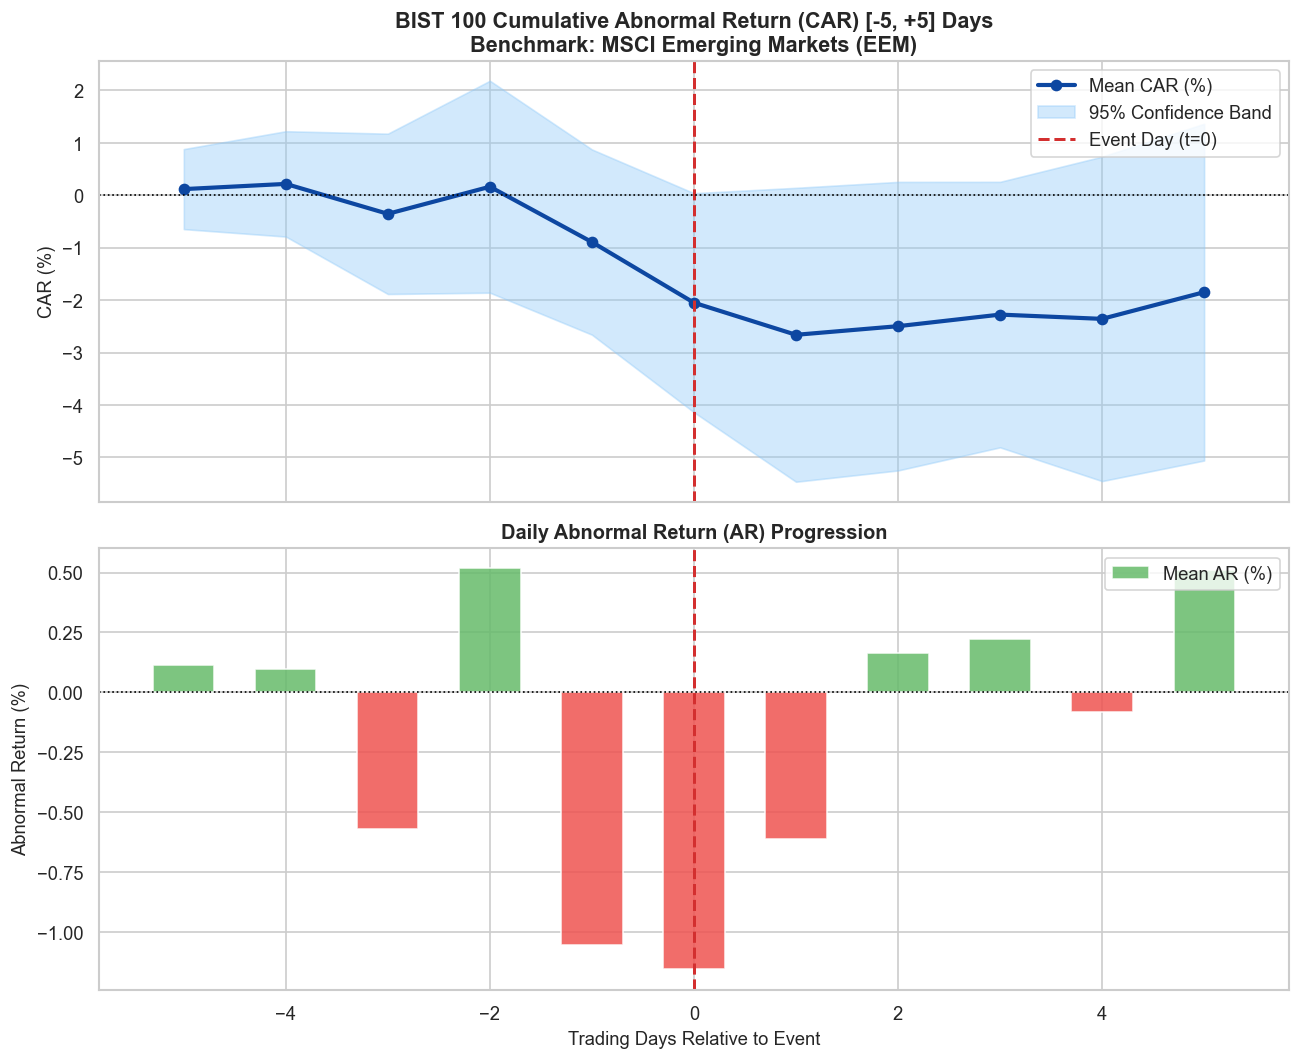

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
days = agg_stats["relative_day"]
mean_car = agg_stats["mean_car_pct"]
se_car = agg_stats["std_car_pct"] / np.sqrt(agg_stats["n_events"])

ax1.plot(days, mean_car, color="#0D47A1", lw=2.5, marker="o", label="Mean CAR (%)")
ax1.fill_between(days, mean_car - 1.96 * se_car, mean_car + 1.96 * se_car, color="#90CAF9", alpha=0.4, label="95% Confidence Band")
ax1.axvline(0, color="#D32F2F", linestyle="--", lw=1.8, label="Event Day (t=0)")
ax1.axhline(0, color="black", linestyle=":", lw=1)
ax1.set_title("BIST 100 Cumulative Abnormal Return (CAR) [-5, +5] Days\nBenchmark: MSCI Emerging Markets (EEM)", fontsize=13, fontweight="bold")
ax1.set_ylabel("CAR (%)", fontsize=11)
ax1.legend(loc="upper right", frameon=True)

colors = ["#EF5350" if x < 0 else "#66BB6A" for x in agg_stats["mean_ar_pct"]]
ax2.bar(days, agg_stats["mean_ar_pct"], color=colors, width=0.6, alpha=0.85, label="Mean AR (%)")
ax2.axvline(0, color="#D32F2F", linestyle="--", lw=1.8)
ax2.axhline(0, color="black", linestyle=":", lw=1)
ax2.set_title("Daily Abnormal Return (AR) Progression", fontsize=12, fontweight="bold")
ax2.set_xlabel("Trading Days Relative to Event", fontsize=11)
ax2.set_ylabel("Abnormal Return (%)", fontsize=11)
ax2.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


## 3. GARCH(1,1) Volatility Dynamics & Shock Persistence
Financial returns exhibit fat tails (leptokurtosis) and time-varying volatility clustering. We fit a GARCH(1,1) model with Student-t innovations and compute volatility persistence and shock half-life.

In [7]:
from matplotlib import transforms
scaled_ret = panel["daily_return"].dropna() * 100.0
am = arch_model(scaled_ret, mean="Constant", vol="GARCH", p=1, q=1, dist="t")
res = am.fit(disp="off")

omega = res.params["omega"]
alpha_1 = res.params["alpha[1]"]
beta_1 = res.params["beta[1]"]
persistence = alpha_1 + beta_1
half_life = np.log(0.5) / np.log(persistence)
ann_uncond_vol = np.sqrt((omega / (1 - persistence)) * 252)

print("--- GARCH(1,1) RESULTS ---")
print(f"Omega:                      {omega:.6f}")
print(f"Alpha (ARCH reaction):      {alpha_1:.4f} (p-val: {res.pvalues['alpha[1]']:.4e})")
print(f"Beta (GARCH memory):       {beta_1:.4f} (p-val: {res.pvalues['beta[1]']:.4e})")
print(f"Persistence (Alpha + Beta): {persistence:.4f}")
print(f"Shock Half-Life:            {half_life:.1f} trading days")
print(f"Long-Term Annualized Vol:   {ann_uncond_vol:.2f}%")

--- GARCH(1,1) RESULTS ---
Omega:                      0.090351
Alpha (ARCH reaction):      0.0684 (p-val: 6.1865e-04)
Beta (GARCH memory):       0.8954 (p-val: 5.0887e-159)
Persistence (Alpha + Beta): 0.9639
Shock Half-Life:            18.8 trading days
Long-Term Annualized Vol:   25.10%


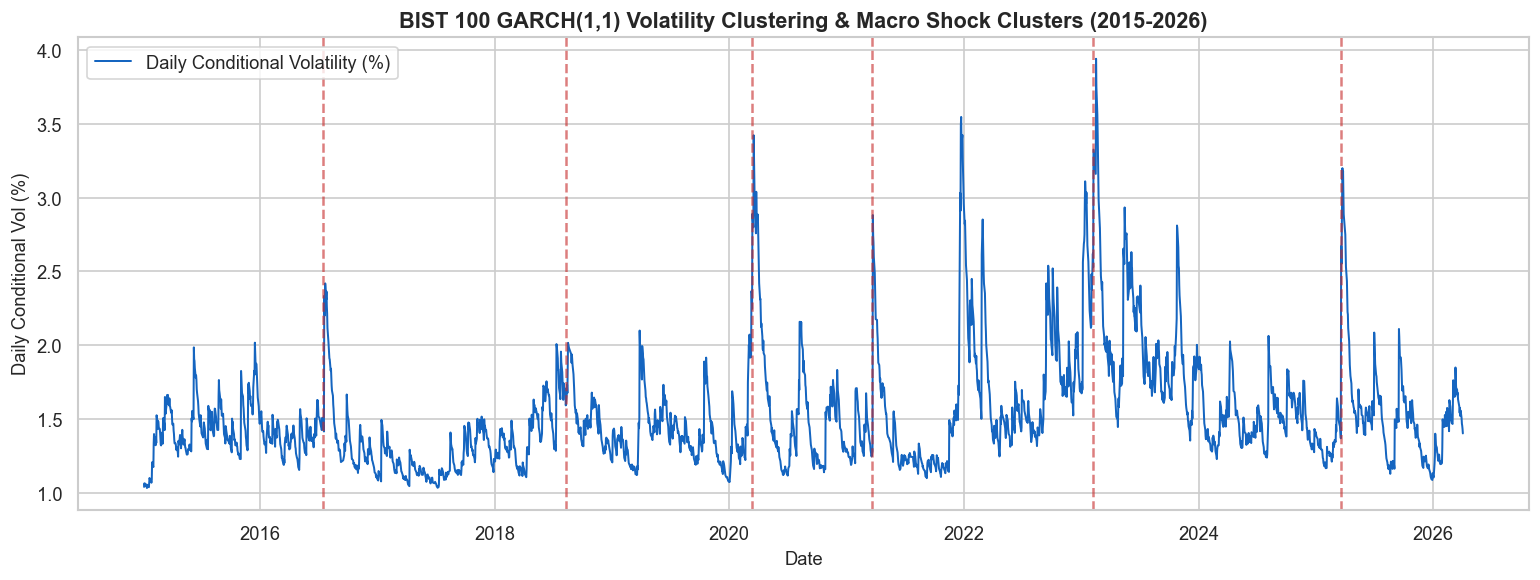

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
panel["cond_vol"] = res.conditional_volatility
ax.plot(panel["date"], panel["cond_vol"], color="#1565C0", lw=1.2, label="Daily Conditional Volatility (%)")

extreme_events = df_shocks[df_shocks["severity"] == "Extreme"]
for _, ev in extreme_events.iterrows():
    ax.axvline(pd.to_datetime(ev["date"]), color="#C62828", alpha=0.6, linestyle="--")

ax.set_title("BIST 100 GARCH(1,1) Volatility Clustering & Macro Shock Clusters (2015-2026)", fontsize=13, fontweight="bold")
ax.set_ylabel("Daily Conditional Vol (%)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()